# Object Resolving from Raw IQ Data

This notebook analyzes CSV files generated by `serial_data_collection_rawiq.py`.
It provides helpers to load data, plot strength per bin, resolve object bins,
track phase across frames, and estimate displacement from phase shift.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from scipy.signal import find_peaks
except Exception:
    find_peaks = None

sns.set_theme(style="whitegrid")


In [2]:
# #region agent log
import json
import time
from pathlib import Path

DEBUG_LOG_PATH = Path('debug-4e8d84.log')

def _debug_log(hypothesis_id, location, message, data):
    payload = {
        'sessionId': '4e8d84',
        'runId': 'pre-fix',
        'hypothesisId': hypothesis_id,
        'location': location,
        'message': message,
        'data': data,
        'timestamp': int(time.time() * 1000),
    }
    with DEBUG_LOG_PATH.open('a', encoding='utf-8') as f:
        f.write(json.dumps(payload) + '\n')
# #endregion


In [3]:
REQUIRED_COLUMNS = [
    "trial",
    "frame_id",
    "sensor_label",
    "sensor_addr_hex",
    "frame_bins",
    "frame_t_ms",
    "register_index_global",
    "bin_index_sensor",
    "I_raw_milli",
    "Q_raw_milli",
]


def load_rawiq_csvs(paths):
    """Load one or many raw-IQ CSV files and add derived IQ columns."""
    if isinstance(paths, (str, Path)):
        paths = [paths]

    frames = []
    for item in paths:
        p = Path(item)
        if p.is_dir():
            for csv_path in sorted(p.glob("*.csv")):
                df = pd.read_csv(csv_path)
                df["source_file"] = str(csv_path)
                frames.append(df)
        else:
            df = pd.read_csv(p)
            df["source_file"] = str(p)
            frames.append(df)

    if not frames:
        raise ValueError("No CSV files found in provided path(s).")

    df = pd.concat(frames, ignore_index=True)
    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    numeric_cols = [
        "trial",
        "frame_id",
        "frame_bins",
        "frame_t_ms",
        "register_index_global",
        "bin_index_sensor",
        "I_raw_milli",
        "Q_raw_milli",
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=numeric_cols).copy()

    for col in numeric_cols:
        df[col] = df[col].astype(int)

    df["I"] = df["I_raw_milli"] / 1000.0
    df["Q"] = df["Q_raw_milli"] / 1000.0
    z = df["I"].to_numpy() + 1j * df["Q"].to_numpy()
    df["strength_per_bin"] = np.abs(z)
    df["phase_rad"] = np.angle(z)

    df = df.sort_values(
        ["trial", "sensor_label", "frame_t_ms", "frame_id", "bin_index_sensor"]
    ).reset_index(drop=True)
    return df


def get_frame(df, trial, sensor_label, frame_id):
    frame = df[
        (df["trial"] == trial)
        & (df["sensor_label"] == sensor_label)
        & (df["frame_id"] == frame_id)
    ].copy()
    if frame.empty:
        raise ValueError("Requested frame selection is empty.")
    return frame.sort_values("bin_index_sensor")


def plot_frame_strength(df, trial, sensor_label, frame_id, ax=None):
    frame = get_frame(df, trial, sensor_label, frame_id)
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    ax.plot(frame['bin_index_sensor'], frame['strength_per_bin'], marker='o', ms=3, lw=1.2)
    ax.set_title(f'Strength per bin | trial={trial}, sensor={sensor_label}, frame={frame_id}')
    ax.set_xlabel('bin_index_sensor')
    ax.set_ylabel('strength (|I + jQ|)')
    return ax


def detect_object_bins(frame_df, min_prominence=0.02, min_distance_bins=2, max_bins=3):
    frame_df = frame_df.sort_values('bin_index_sensor').copy()
    x = frame_df['bin_index_sensor'].to_numpy()
    y = frame_df['strength_per_bin'].to_numpy()

    if y.size == 0:
        return pd.DataFrame(columns=['bin_index_sensor', 'strength_per_bin', 'score'])

    if find_peaks is not None:
        peak_idx, props = find_peaks(y, prominence=min_prominence, distance=min_distance_bins)
        prominences = props.get('prominences', np.zeros_like(peak_idx, dtype=float))
        peaks = pd.DataFrame({
            'bin_index_sensor': x[peak_idx],
            'strength_per_bin': y[peak_idx],
            'score': prominences,
        })
    else:
        peaks = pd.DataFrame({
            'bin_index_sensor': x,
            'strength_per_bin': y,
            'score': y,
        })

    if peaks.empty:
        return peaks

    peaks = peaks.sort_values(['score', 'strength_per_bin'], ascending=False).head(max_bins)
    return peaks.reset_index(drop=True)


In [4]:
def plot_phase_shift_between_trials(df, sensor_label, reference_bin, frame_selector='first'):
    """Compute phase shift per trial for a fixed sensor/bin selection."""
    sub = df[df['sensor_label'] == sensor_label].copy()
    if sub.empty:
        raise ValueError('No rows found for requested sensor label.')

    rows = []
    for trial, trial_df in sub.groupby('trial', sort=True):
        trial_df = trial_df.sort_values(['frame_t_ms', 'frame_id', 'bin_index_sensor'])

        if frame_selector == 'first':
            frame_id = int(trial_df['frame_id'].iloc[0])
        elif frame_selector == 'last':
            frame_id = int(trial_df['frame_id'].iloc[-1])
        else:
            frame_id = int(frame_selector)

        frame_df = trial_df[trial_df['frame_id'] == frame_id].copy()
        if frame_df.empty:
            continue

        idx = (frame_df['bin_index_sensor'] - reference_bin).abs().idxmin()
        row = frame_df.loc[idx]
        phase_val = float(row['phase_rad'])
        rows.append({
            'trial': int(trial),
            'frame_id': frame_id,
            'frame_t_ms': int(row['frame_t_ms']),
            'bin_index_sensor': int(row['bin_index_sensor']),
            'strength_per_bin': float(row['strength_per_bin']),
            'phase_rad': phase_val,
        })

    out = pd.DataFrame(rows).sort_values('trial').reset_index(drop=True)
    if out.empty:
        raise ValueError('No trial-level phase rows were produced.')

    out['phase_unwrapped_rad'] = np.unwrap(out['phase_rad'].to_numpy())
    out['phase_shift_rad'] = out['phase_unwrapped_rad'] - out['phase_unwrapped_rad'].iloc[0]
    return out


def estimate_displacement_mm_from_phase(phase_shift_rad, wavelength_mm=5.0):
    """Monostatic approximation: phase_shift = 4*pi*delta_r/lambda."""
    return (phase_shift_rad * wavelength_mm) / (4.0 * np.pi)


def plot_phase_shift_and_displacement_between_trials(trial_phase_df, wavelength_mm=5.0):
    out = trial_phase_df.copy()
    out['displacement_mm'] = estimate_displacement_mm_from_phase(
        out['phase_shift_rad'].to_numpy(), wavelength_mm=wavelength_mm
    )

    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    axes[0].plot(out['trial'], out['phase_shift_rad'], marker='o')
    axes[0].set_ylabel('phase shift (rad)')
    axes[0].set_title('Object phase shift between trials')

    axes[1].plot(out['trial'], out['displacement_mm'], marker='o', color='tab:orange')
    axes[1].set_ylabel('displacement (mm)')
    axes[1].set_xlabel('trial')
    axes[1].set_title('Estimated displacement between trials')
    plt.tight_layout()
    return out, axes

# #region agent log
_debug_log('H1', 'object_resolving.ipynb:function_cell', 'function symbols after definition cell', {
    'has_plot_frame_strength': 'plot_frame_strength' in globals(),
    'has_detect_object_bins': 'detect_object_bins' in globals(),
    'has_plot_phase_shift_between_trials': 'plot_phase_shift_between_trials' in globals(),
})
# #endregion


## End-to-End Pipeline

Set the inputs below, then run this cell to load CSV data, find object bins,
track phase over time, and visualize estimated displacement.


,trial,frame_id,sensor_label,sensor_addr_hex,frame_bins,frame_t_ms,register_index_global,bin_index_sensor,I_raw_milli,Q_raw_milli,source_file,I,Q,strength_per_bin,phase_rad
0,0,0,BACK,52,65,52684,0,0,4528200,-3958800,..\data\raw_iq_test_3.csv,4528.2,-3958.8,6014.706367,-0.718408
1,0,0,BACK,52,65,52684,1,1,0,-1691800,..\data\raw_iq_test_3.csv,0.0,-1691.8,1691.800000,-1.570796
2,0,0,BACK,52,65,52684,2,2,0,-746900,..\data\raw_iq_test_3.csv,0.0,-746.9,746.900000,-1.570796
3,0,0,BACK,52,65,52684,3,3,0,-1318800,..\data\raw_iq_test_3.csv,0.0,-1318.8,1318.800000,-1.570796
4,0,0,BACK,52,65,52684,4,4,0,-210700,..\data\raw_iq_test_3.csv,0.0,-210.7,210.700000,-1.570796


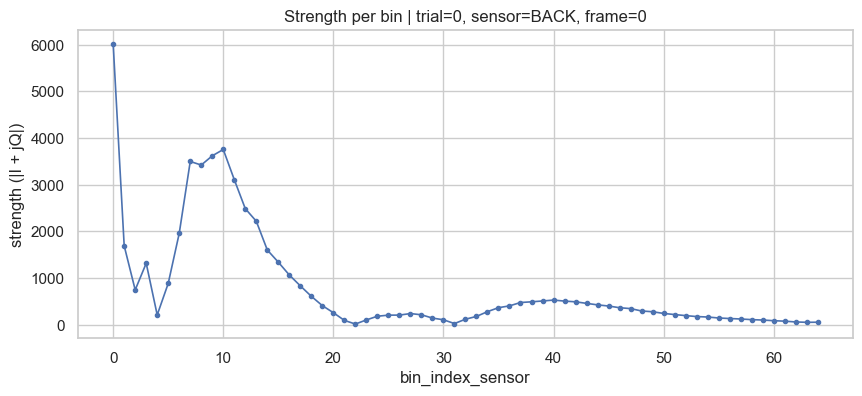

,bin_index_sensor,strength_per_bin,score
0,10,3755.6,3544.9
1,3,1318.8,571.9
2,40,529.3,476.3


Selected target bin: 10


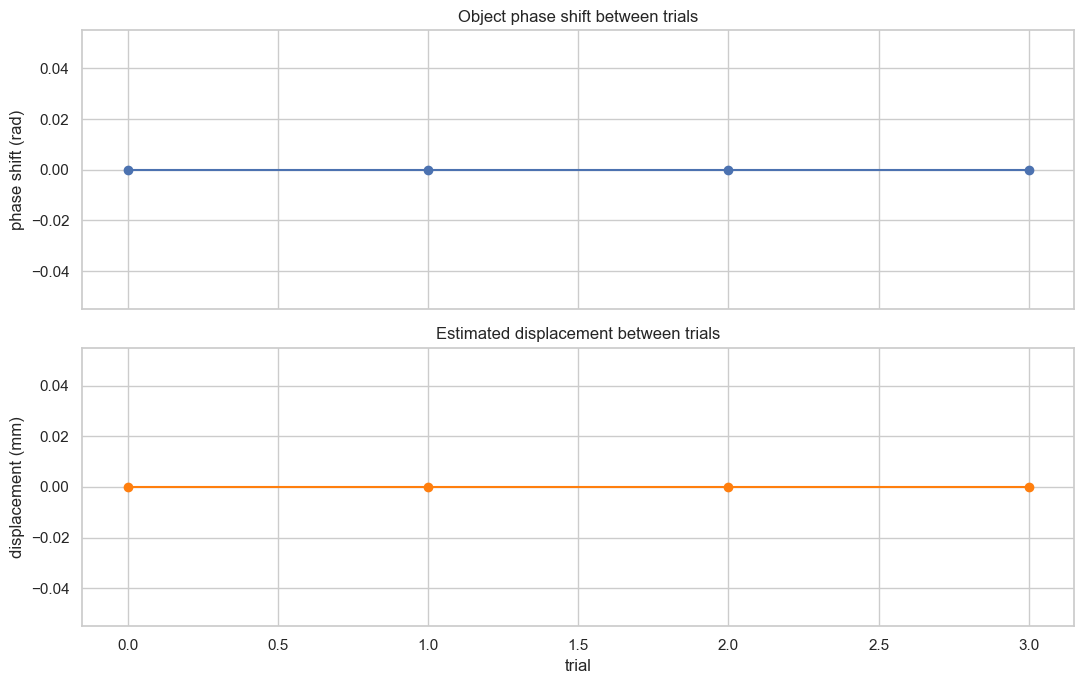

,trial,frame_id,frame_t_ms,bin_index_sensor,strength_per_bin,phase_rad,phase_unwrapped_rad,phase_shift_rad,displacement_mm
0,0,0,52684,10,3755.6,1.570796,1.570796,0.0,0.0
1,1,4,66554,10,3527.5,1.570796,1.570796,0.0,0.0
2,2,8,80424,10,3286.6,1.570796,1.570796,0.0,0.0
3,3,12,94293,10,3700.0,1.570796,1.570796,0.0,0.0


Interpretation: phase shift between trials captures net motion/change between trial conditions; displacement scale depends on wavelength and geometry assumptions.


In [5]:
# User inputs
CSV_INPUT = Path('../data/raw_iq_test_3.csv')  # e.g. Path('../data/rawiq_capture.csv')
TRIAL = 0
SENSOR = 'BACK'
FRAME_WINDOW = None  # e.g. (20, 80) inclusive frame_id window
MIN_PROMINENCE = 0.02
MIN_DISTANCE_BINS = 2
MAX_OBJECT_BINS = 3
WAVELENGTH_MM = 5.0
FRAME_SELECTOR_FOR_TRIAL_COMPARE = 'first'  # 'first', 'last', or explicit frame_id

# 1) Load and select
df = load_rawiq_csvs(CSV_INPUT)
display(df.head())

subset = df[(df['trial'] == TRIAL) & (df['sensor_label'] == SENSOR)].copy()
if subset.empty:
    raise ValueError('No data found for selected TRIAL/SENSOR.')

frames = np.sort(subset['frame_id'].unique())
if FRAME_WINDOW is not None:
    f0, f1 = FRAME_WINDOW
    frames = np.array([f for f in frames if f0 <= f <= f1], dtype=int)
if len(frames) == 0:
    raise ValueError('No frames available after applying FRAME_WINDOW.')

seed_frame_id = int(frames[0])
seed_frame = get_frame(df, TRIAL, SENSOR, seed_frame_id)

# 2) Plot a frame of IQ strength per bin
# #region agent log
_debug_log('H2', 'object_resolving.ipynb:pipeline', 'pre plot_frame_strength call symbol check', {
    'has_plot_frame_strength': 'plot_frame_strength' in globals(),
    'seed_frame_id': int(seed_frame_id),
    'trial': int(TRIAL),
    'sensor': SENSOR,
})
# #endregion
plot_frame_strength(df, TRIAL, SENSOR, seed_frame_id)
plt.show()

# 3) Resolve candidate object bins
candidates = detect_object_bins(
    seed_frame,
    min_prominence=MIN_PROMINENCE,
    min_distance_bins=MIN_DISTANCE_BINS,
    max_bins=MAX_OBJECT_BINS,
)
display(candidates)
if candidates.empty:
    raise ValueError('No object candidates detected in seed frame.')

target_bin = int(candidates.iloc[0]['bin_index_sensor'])
print(f'Selected target bin: {target_bin}')

# 4) Compare phase shift between trials (same sensor/bin)
trial_phase = plot_phase_shift_between_trials(
    df=df,
    sensor_label=SENSOR,
    reference_bin=target_bin,
    frame_selector=FRAME_SELECTOR_FOR_TRIAL_COMPARE,
)
trial_out, _ = plot_phase_shift_and_displacement_between_trials(
    trial_phase_df=trial_phase,
    wavelength_mm=WAVELENGTH_MM,
)
plt.show()

display(trial_out.head())
print(
    'Interpretation: phase shift between trials captures net motion/change between trial conditions; '
    'displacement scale depends on wavelength and geometry assumptions.'
)
